In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wangapa106g/kenya-data/kenya_mock.geojson
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/coordinates.ts
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/LICENSE
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/counties.ts
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/README.md
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/osm-ids.ts
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/osm-ids.json
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/counties.json
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/generate-geometries.py
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/geojson/embu.json
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/geojson/meru.json
/ka

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
donors  = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/donors.csv")
donation = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/danations.csv")
candidates  = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/candidates.csv")
election_timeline = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/election_timeline.csv")
public_projects = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/public_projects.csv")

In [4]:
donations_full = donation.merge(candidates, on="candidate_id") \
                          .merge(donors, on="donor_id")

donations_full.head()

,donation_id,candidate_id,donor_id,amount,date,name,party,county_x,position,donor_name,donor_type,county_y
0,1001,1,101,5000000,2026-05-10,James Mwangi,Reform Party,Nairobi,Governor,BlueWave Contractors Ltd,Company,Nairobi
1,1002,1,103,200000,2026-05-12,James Mwangi,Reform Party,Nairobi,Governor,John Kamau,Individual,Nairobi
2,1003,2,104,3000000,2026-06-01,Faith Achieng,Unity Party,Kisumu,Governor,Victoria Traders Ltd,Company,Kisumu
3,1004,2,105,150000,2026-06-03,Faith Achieng,Unity Party,Kisumu,Governor,Peter Otieno,Individual,Kisumu
4,1005,3,106,4500000,2026-06-15,David Kiptoo,National Alliance,Uasin Gishu,Senator,Rift Infrastructure Ltd,Company,Uasin Gishu


In [5]:
donor_totals = donations_full.groupby(
    ["candidate_id","donor_id"]
)["amount"].sum().reset_index()

candidate_totals = donations_full.groupby(
    "candidate_id"
)["amount"].sum().reset_index()

merged = donor_totals.merge(
    candidate_totals,
    on="candidate_id",
    suffixes=("_donor","_total")
)

merged["donor_share"] = merged["amount_donor"] / merged["amount_total"]

merged.sort_values("donor_share", ascending=False)

,candidate_id,donor_id,amount_donor,amount_total,donor_share
6,5,107,2500000,2500000,1.000000
5,4,102,4000000,4000000,1.000000
4,3,106,4500000,4500000,1.000000
0,1,101,8000000,8200000,0.975610
2,2,104,3000000,3150000,0.952381
3,2,105,150000,3150000,0.047619
1,1,103,200000,8200000,0.024390


In [6]:
overlap = donations_full.merge(
    public_projects,
    left_on="donor_name",
    right_on="contractor"
)

overlap[[
    "candidate_id",
    "donor_name",
    "county_x",
    "project_value"
]]

,candidate_id,donor_name,county_x,project_value
0,1,BlueWave Contractors Ltd,Nairobi,15000000
1,2,Victoria Traders Ltd,Kisumu,12000000
2,3,Rift Infrastructure Ltd,Uasin Gishu,18000000
3,4,Sunrise Holdings Ltd,Nakuru,14000000
4,5,Coastal Supplies Ltd,Mombasa,10000000
5,1,BlueWave Contractors Ltd,Nairobi,15000000


In [7]:
donations_full = donation.merge(candidates, on="candidate_id") \
                          .merge(donors, on="donor_id")

donations_full.head()

,donation_id,candidate_id,donor_id,amount,date,name,party,county_x,position,donor_name,donor_type,county_y
0,1001,1,101,5000000,2026-05-10,James Mwangi,Reform Party,Nairobi,Governor,BlueWave Contractors Ltd,Company,Nairobi
1,1002,1,103,200000,2026-05-12,James Mwangi,Reform Party,Nairobi,Governor,John Kamau,Individual,Nairobi
2,1003,2,104,3000000,2026-06-01,Faith Achieng,Unity Party,Kisumu,Governor,Victoria Traders Ltd,Company,Kisumu
3,1004,2,105,150000,2026-06-03,Faith Achieng,Unity Party,Kisumu,Governor,Peter Otieno,Individual,Kisumu
4,1005,3,106,4500000,2026-06-15,David Kiptoo,National Alliance,Uasin Gishu,Senator,Rift Infrastructure Ltd,Company,Uasin Gishu


In [8]:
# Total per donor per candidate
donor_totals = donations_full.groupby(
    ["candidate_id", "donor_id"]
)["amount"].sum().reset_index()

# Total donations per candidate
candidate_totals = donations_full.groupby(
    "candidate_id"
)["amount"].sum().reset_index()

# Merge totals
merged = donor_totals.merge(
    candidate_totals,
    on="candidate_id",
    suffixes=("_donor", "_total")
)

# Calculate donor share
merged["donor_share"] = merged["amount_donor"] / merged["amount_total"]

merged

,candidate_id,donor_id,amount_donor,amount_total,donor_share
0,1,101,8000000,8200000,0.975610
1,1,103,200000,8200000,0.024390
2,2,104,3000000,3150000,0.952381
3,2,105,150000,3150000,0.047619
4,3,106,4500000,4500000,1.000000
5,4,102,4000000,4000000,1.000000
6,5,107,2500000,2500000,1.000000


In [9]:
merged["concentration_risk"] = np.where(
    merged["donor_share"] > 0.6,
    1,
    0
)

merged

,candidate_id,donor_id,amount_donor,amount_total,donor_share,concentration_risk
0,1,101,8000000,8200000,0.975610,1
1,1,103,200000,8200000,0.024390,0
2,2,104,3000000,3150000,0.952381,1
3,2,105,150000,3150000,0.047619,0
4,3,106,4500000,4500000,1.000000,1
5,4,102,4000000,4000000,1.000000,1
6,5,107,2500000,2500000,1.000000,1


In [10]:
concentration_score = merged.groupby(
    "candidate_id"
)["concentration_risk"].max().reset_index()

concentration_score

,candidate_id,concentration_risk
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [11]:
kenya_map = gpd.read_file("/kaggle/input/datasets/wangapa106g/kenya-data/kenya_mock.geojson")

kenya_map.head()

,county_name,geometry
0,Nairobi,"POLYGON ((36.75 -1.15, 36.95 -1.15, 36.95 -1.3..."
1,Kisumu,"POLYGON ((34.65 0, 34.85 0, 34.85 -0.2, 34.65 ..."
2,Uasin Gishu,"POLYGON ((35.15 0.45, 35.35 0.45, 35.35 0.25, ..."


In [12]:
overlap_score = overlap[["candidate_id"]].drop_duplicates()
overlap_score["overlap_risk"] = 1

In [13]:
risk = candidates[["candidate_id","county"]] \
    .merge(concentration_score, on="candidate_id", how="left") \
    .merge(overlap_score, on="candidate_id", how="left")

risk = risk.fillna(0)

In [14]:
risk["PFRS"] = (
    0.4 * risk["concentration_risk"] +
    0.4 * risk["overlap_risk"] +
    0.2 * np.random.rand(len(risk))
)

risk.sort_values("PFRS", ascending=False)

,candidate_id,county,concentration_risk,overlap_risk,PFRS
0,1,Nairobi,1,1,0.912533
2,3,Uasin Gishu,1,1,0.906947
3,4,Nakuru,1,1,0.897976
1,2,Kisumu,1,1,0.830971
4,5,Mombasa,1,1,0.813718


In [15]:
county_risk = risk.groupby("county")["PFRS"].mean().reset_index()

county_risk

,county,PFRS
0,Kisumu,0.830971
1,Mombasa,0.813718
2,Nairobi,0.912533
3,Nakuru,0.897976
4,Uasin Gishu,0.906947


In [16]:
geo_risk = kenya_map.merge(
    county_risk,
    left_on="county_name",
    right_on="county",
    how="left"
)

geo_risk

,county_name,geometry,county,PFRS
0,Nairobi,"POLYGON ((36.75 -1.15, 36.95 -1.15, 36.95 -1.3...",Nairobi,0.912533
1,Kisumu,"POLYGON ((34.65 0, 34.85 0, 34.85 -0.2, 34.65 ...",Kisumu,0.830971
2,Uasin Gishu,"POLYGON ((35.15 0.45, 35.35 0.45, 35.35 0.25, ...",Uasin Gishu,0.906947


In [17]:
import geopandas as gpd
import os

folder_path = "/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/geojson"  # your folder name

gdfs = []

for file in os.listdir(folder_path):
    if file.endswith(".json"):
        path = os.path.join(folder_path, file)
        gdf = gpd.read_file(path)
        gdfs.append(gdf)

# Combine all counties
kenya_counties = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

kenya_counties.head()

,geometry
0,GEOMETRYCOLLECTION (MULTIPOLYGON (((37.26792 -...
1,GEOMETRYCOLLECTION (MULTIPOLYGON (((37.11994 -...
2,GEOMETRYCOLLECTION (MULTIPOLYGON (((35.15229 1...
3,GEOMETRYCOLLECTION (MULTIPOLYGON (((33.93142 -...
4,GEOMETRYCOLLECTION (MULTIPOLYGON (((36.00092 -...


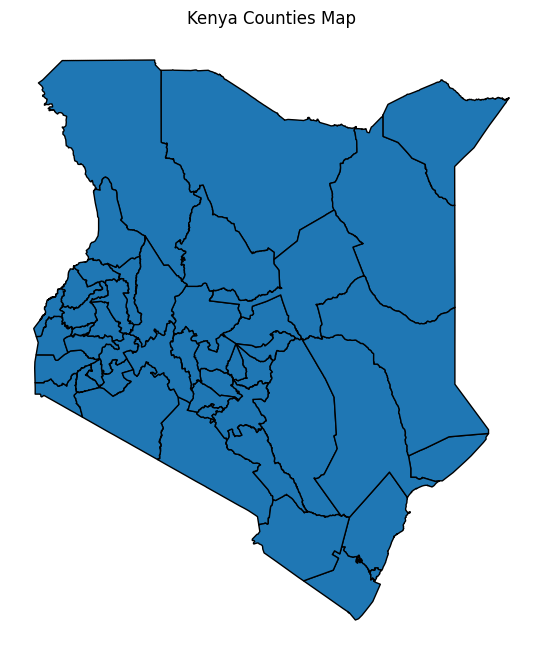

In [18]:
import matplotlib.pyplot as plt

kenya_counties.plot(
    edgecolor="black",
    figsize=(10, 8)
)

plt.title("Kenya Counties Map")
plt.axis("off")
plt.show()

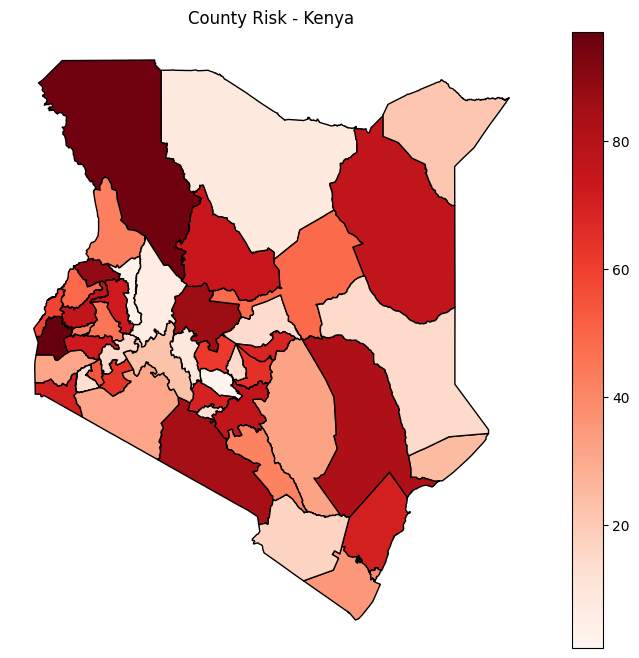

In [19]:
import numpy as np

kenya_counties["PFRS"] = np.random.uniform(0, 100, len(kenya_counties))

kenya_counties.plot(
    column="PFRS",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    figsize=(10, 8)
)

plt.title("County Risk - Kenya")
plt.axis("off")
plt.show()